In [1]:
from analyze import *
import os

# look through flight_data folder for files containing "aug" (lowercase or uppercase)
# and print out the file names with numbers
files = [f for f in os.listdir("flight_data")]
for i, f in enumerate(files):
    print(i, f)

0 Sep4_5inch_icra_5inch_0percent_randomized_crash1.csv
1 Sep5_3inch_0percent_randomized_1runs_succesful.csv
2 Sep5_3inch_20percent_randomized_3runs_succesful.csv
3 Sep4_5inch_icra_5inch_10percent_randomized_2_runs_succesful.csv
4 Sep5_3inch_10percent_randomized_3runs_succesful.csv
5 Sep4_5inch_icra_5inch_10percent_randomized_1_runs_succesful.csv
6 Sep4_5inch_icra_5inch_0percent_randomized_crash3.csv
7 Sep5_3inch_0percent_randomized_2runs_succesful_1_optitrack_loss.csv
8 Sep4_5inch_icra_big_domain_randomization_3_3succesfull_runs.csv
9 Sep4_5inch_icra_5inch_0percent_randomized_crash2.csv
10 Sep5_3inch_big_randomization_3runs_succesful.csv
11 Sep5_3inch_30percent_randomized_3runs_succesful.csv
12 Sep4_5inch_icra_5inch_30percent_randomized_3_3succesfull_runs.csv
13 Sep4_5inch_icra_5inch_20percent_randomized_3_3succesfull_runs.csv


In [2]:
def trim_nn_active(data):
    indices = data['flightModeFlags'] > 8000
    data = {k: v[indices] for k, v in data.items() if isinstance(v, np.ndarray) and len(v) == len(indices)}
    data['t'] = data['t'] - data['t'][0]
    return data

def trim_time(data, t0=0, tf=12):
    indices = (data['t'] >= t0) & (data['t'] <= tf)
    try:
        # add one more data point to make sure that t=tf is included
        i = np.min(np.where(data['t']>tf)[0])
        indices[i] = True
    except:
        print("Warning: tf is greater than the last time point")
    data = {k: v[indices] for k, v in data.items() if isinstance(v, np.ndarray) and len(v) == len(indices)}
    data['t'] = data['t'] - data['t'][0]
    return data

def split_where_nn_active(data):
    # plt.plot(data['flightModeFlags'])
    # plt.show()
    nn_active = data['flightModeFlags'] > 8000
    nn_activate = [i for i in range(1, len(nn_active)) if nn_active[i] and not nn_active[i-1]]
    nn_deactivate = [i for i in range(1, len(nn_active)) if not nn_active[i] and nn_active[i-1]]
    # make sure nn_activate and nn_deactivate are the same length
    if len(nn_activate) > len(nn_deactivate):
        nn_deactivate.append(len(nn_active))
    split_data = []
    for i in range(len(nn_activate)):
        split_data.append({k: v[nn_activate[i]:nn_deactivate[i]] for k, v in data.items() if isinstance(v, np.ndarray) and len(v) == len(data['t'])})
        split_data[-1]['t'] = split_data[-1]['t'] - split_data[-1]['t'][0]
    return split_data

In [3]:
# animate
# race track
r = 1.5
gate_pos = np.array([
    [ r,  -r, -1.5],
    [ 0,   0, -1.5],
    [-r,   r, -1.5],
    [ 0, 2*r, -1.5],
    [ r,   r, -1.5],
    [ 0,   0, -1.5],
    [-r,  -r, -1.5],
    [ 0,-2*r, -1.5]
])
gate_yaw = np.array([1,2,1,0,-1,-2,-1,0])*np.pi/2

## Load and prepare flight data

In [4]:
# 3INCH DRONE----------------------------------------------------------------------------
# 3inch big randomization
data = load_flight_data("flight_data/Sep5_3inch_big_randomization_3runs_succesful.csv")
runs = split_where_nn_active(data)
runs_3inch_big_domain_randomization = [trim_time(r, t0=0, tf=12) for r in runs]
print(runs_3inch_big_domain_randomization[0]['t'][-1])

# 3inch 30 percent randomization
data = load_flight_data("flight_data/Sep5_3inch_30percent_randomized_3runs_succesful.csv")
runs = split_where_nn_active(data)
runs_3inch_30percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 3inch 20 percent randomization
data = load_flight_data("flight_data/Sep5_3inch_20percent_randomized_3runs_succesful.csv")
runs = split_where_nn_active(data)
runs_3inch_20percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 3inch 10 percent randomization
data = load_flight_data("flight_data/Sep5_3inch_10percent_randomized_3runs_succesful.csv")
runs = split_where_nn_active(data)
runs_3inch_10percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 3inch 0 percent randomization
data1 = load_flight_data("flight_data/Sep5_3inch_0percent_randomized_2runs_succesful_1_optitrack_loss.csv")
data2 = load_flight_data("flight_data/Sep5_3inch_0percent_randomized_1runs_succesful.csv")
runs = split_where_nn_active(data1)
# remove the last run because it's not a full run (optitrack loss)
runs = runs[:-1]
# append the last run
runs.append(split_where_nn_active(data2)[0])
runs_3inch_0percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 5INCH DRONE----------------------------------------------------------------------------
# 5inch big randomization
data = load_flight_data("flight_data/Sep4_5inch_icra_big_domain_randomization_3_3succesfull_runs.csv")
runs = split_where_nn_active(data)
runs_5inch_big_domain_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 5inch 30 percent randomization
data = load_flight_data("flight_data/Sep4_5inch_icra_5inch_30percent_randomized_3_3succesfull_runs.csv")
runs = split_where_nn_active(data)
runs_5inch_30percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 5inch 20 percent randomization
data = load_flight_data("flight_data/Sep4_5inch_icra_5inch_20percent_randomized_3_3succesfull_runs.csv")
runs = split_where_nn_active(data)
runs_5inch_20percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 5inch 10 percent randomization
data1 = load_flight_data("flight_data/Sep4_5inch_icra_5inch_10percent_randomized_2_runs_succesful.csv")
data2 = load_flight_data("flight_data/Sep4_5inch_icra_5inch_10percent_randomized_1_runs_succesful.csv")
runs = split_where_nn_active(data1)[0:2]
runs.append(split_where_nn_active(data2)[0])
runs_5inch_10percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

# 5inch 0 percent randomization
data1 = load_flight_data("flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash1.csv")
data2 = load_flight_data("flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash2.csv")
data3 = load_flight_data("flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash3.csv")
runs = [split_where_nn_active(data1)[0], split_where_nn_active(data2)[0], split_where_nn_active(data3)[0]]
runs_5inch_0percent_randomization = [trim_time(r, t0=0, tf=12) for r in runs]

Loading flight_data/Sep5_3inch_big_randomization_3runs_succesful.csv
Logging frequency: 906.2990724728469
12.000248999999997
Loading flight_data/Sep5_3inch_30percent_randomized_3runs_succesful.csv
Logging frequency: 881.7974382601424
Loading flight_data/Sep5_3inch_20percent_randomized_3runs_succesful.csv
Logging frequency: 872.9291493196605
Loading flight_data/Sep5_3inch_10percent_randomized_3runs_succesful.csv
Logging frequency: 902.7468512313426
Loading flight_data/Sep5_3inch_0percent_randomized_2runs_succesful_1_optitrack_loss.csv
Logging frequency: 880.4374784409089
Loading flight_data/Sep5_3inch_0percent_randomized_1runs_succesful.csv
Logging frequency: 875.9575368790433
Loading flight_data/Sep4_5inch_icra_big_domain_randomization_3_3succesfull_runs.csv
Logging frequency: 927.5923996154623
Loading flight_data/Sep4_5inch_icra_5inch_30percent_randomized_3_3succesfull_runs.csv
Logging frequency: 896.8315739388388
Loading flight_data/Sep4_5inch_icra_5inch_20percent_randomized_3_3succe

/home/robin/optimal_quad_control_RL/analyze.py:138: RuntimeWarning: invalid value encountered in arcsin
  data['theta'] = np.arcsin(2*(data['qw']*data['qy'] - data['qz']*data['qx']))


Loading flight_data/Sep4_5inch_icra_5inch_10percent_randomized_2_runs_succesful.csv
Logging frequency: 953.496203382087
Loading flight_data/Sep4_5inch_icra_5inch_10percent_randomized_1_runs_succesful.csv
Logging frequency: 990.4674567572033
Loading flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash1.csv
Logging frequency: 943.4450292555804
Loading flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash2.csv
Logging frequency: 947.9262068713646
Loading flight_data/Sep4_5inch_icra_5inch_0percent_randomized_crash3.csv
Logging frequency: 939.8871644874367


In [5]:
runs = runs_3inch_big_domain_randomization + runs_3inch_30percent_randomization + runs_3inch_20percent_randomization + runs_3inch_10percent_randomization + runs_3inch_0percent_randomization
names = ["big"]*3 + ["30%"]*3 + ["20%"]*3 + ["10%"]*3 + ["0%"]*3
colors = [(255,0,0)]*3 + [(0,255,0)]*3 + [(0,0,255)]*3 + [(0,255,255)]*3 + [(0,0,0)]*3
animate_data_multiple(*runs, gate_pos=gate_pos, gate_yaw=gate_yaw, names=names, colors=colors)

runs = runs_5inch_big_domain_randomization + runs_5inch_30percent_randomization + runs_5inch_20percent_randomization + runs_5inch_10percent_randomization + runs_5inch_0percent_randomization
names = ["big"]*3 + ["30%"]*3 + ["20%"]*3 + ["10%"]*3 + ["0%"]*3
colors = [(255,0,0)]*3 + [(0,255,0)]*3 + [(0,0,255)]*3 + [(0,255,255)]*3 + [(0,0,0)]*3
animate_data_multiple(*runs, gate_pos=gate_pos, gate_yaw=gate_yaw, names=names, colors=colors)

# Calculate episode information from flight data

In [8]:
# down sample the data
def down_sample(run, freq):
    # subsample the data so it is freq Hz
    t = run['t']
    indices = [0]
    i = 1
    for j in range(1, len(t)):
        if t[j] >= i/freq:
            indices.append(j)
            i += 1
    # printing
    for i in range(len(indices)):
        # print(t[indices[i]], '==', i/freq)
        # check if t[indices[i]] rounded to 2 decimal places is equal to i/freq
        if round(t[indices[i]], 2) != round(i/freq, 2):
            print('ERROR')
            print(t[indices])
            print(t[indices[i]], '!=', i/freq)
    # print('tf=', t[indices[-1]])
    run = {k: v[indices] for k, v in run.items() if isinstance(v, np.ndarray) and len(v) == len(t)}
    return run
    
# get episode info
def get_episode_info(run, gate_pos=gate_pos, gate_yaw=gate_yaw):
    # down sample to 100 Hz to match simulation
    run = down_sample(run, freq=100)
    
    # position
    x, y, z = run['ekf_x'], run['ekf_y'], run['ekf_z']
    pos = np.array([x, y, z]).T
    # body rates
    p, q, r = run['p'], run['q'], run['r']
    rates = np.array([p, q, r]).T
    # target gate
    target_gate = 0
    
    # we will log the following
    pos_list = []
    reward_list = []
    done_list = []
    gate_passed_list = []
    gate_missed_list = []
    
    # run through the data
    for i in range(1, len(pos)):
        pos_old = pos[i-1]
        pos_new = pos[i]
        pos_gate = gate_pos[target_gate]
        yaw_gate = gate_yaw[target_gate]
        
        d2g_old = np.linalg.norm(pos_old - pos_gate)
        d2g_new = np.linalg.norm(pos_new - pos_gate)
        
        reward = d2g_old - d2g_new                  # progress reward
        reward += -0.001*np.linalg.norm(rates[i])   # rate penalty
        
        # gate passing/collision
        normal = [np.cos(yaw_gate), np.sin(yaw_gate)]
        pos_old_projected = (pos_old[0]-pos_gate[0])*normal[0] + (pos_old[1]-pos_gate[1])*normal[1]
        pos_new_projected = (pos_new[0]-pos_gate[0])*normal[0] + (pos_new[1]-pos_gate[1])*normal[1]
        passed_gate_plane = (pos_old_projected < 0) and (pos_new_projected >= 0)
        gate_size = 1.5
        gate_passed = passed_gate_plane and np.all(np.abs(pos_new - pos_gate) < gate_size/2)
        gate_missed = passed_gate_plane and np.any(np.abs(pos_new - pos_gate) > gate_size/2)
        
        # ground collision penalty (z>0)
        ground_collision = pos_new[2] > 0
        if ground_collision:
            reward -= 10
            print('ground collision')
        
        # check out of bounds
        out_of_bounds = np.any(np.abs(pos_new[0:2]) > 5)    # edges of the grid
        out_of_bounds |= pos_new[2] < -7.5                  # max height (z-axis points down)
        out_of_bounds |= np.any(np.abs(rates[i]) > 1000)    # max rate (prevent numerical issues)
        if out_of_bounds:
            reward -= 10
            
        # check number of steps
        max_steps_reached = i >= 1200
        
        # update target gate
        if gate_passed:
            target_gate += 1
            target_gate %= len(gate_pos)
        
        # check if episode is done
        done = max_steps_reached or ground_collision or out_of_bounds or gate_missed
        
        # log
        pos_list.append(pos_new)
        reward_list.append(reward)
        done_list.append(done)
        gate_passed_list.append(gate_passed)
        gate_missed_list.append(gate_missed)
    
    # convert to numpy arrays
    pos = np.array(pos_list)
    rewards = np.array(reward_list)
    dones = np.array(done_list)
    gate_passed = np.array(gate_passed_list)
    gate_missed = np.array(gate_missed_list)
    
    # compute episode reward
    terminal_step = min(np.where(dones)[0])
    ep_reward = np.sum(rewards[:terminal_step+1])
    
    # # print out the results for debugging
    # for i in range(len(rewards)):
    #     print('step:', i, 'reward:', rewards[i], 'done:', dones[i], 'gate_passed:', gate_passed[i], 'gate_missed:', gate_missed[i])
    #     if dones[i]:
    #         print('---------------done---------------')
    
    # print('--------')
    # print('ep_reward=', ep_reward)
    # print('num_gates_passed=', np.sum(gate_passed_list), 'num_gates_missed=', np.sum(gate_missed_list))
    
    info = {
        't': run['t'],
        'pos': pos,
        'rewards': rewards,
        'ep_reward': ep_reward,
        'dones': dones,
        'gates_passed': gate_passed,
        'gates_missed': gate_missed,
        'terminal_step': terminal_step
    }
    
    return info

In [9]:
# add episode info to runs
for run in runs_3inch_big_domain_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_3inch_30percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_3inch_20percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_3inch_10percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_3inch_0percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_5inch_big_domain_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_5inch_30percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_5inch_20percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_5inch_10percent_randomization:
    run['episode_info'] = get_episode_info(run)
for run in runs_5inch_0percent_randomization:
    run['episode_info'] = get_episode_info(run)

# Simulate the policies with identical ICs as the real flights

In [85]:
from quad_race_env import *
from randomization import *
from stable_baselines3 import PPO

device = torch.device("cpu")
torch.set_default_device(device)

# NN MODELS
# models/nn_size_comparison/run1_64_64_64/98000000.zip
# models/3inch_drone/run0_fixed_3inch/59000000.zip
# models/3inch_drone/run0_3inch_10_percent/55000000.zip
# models/3inch_drone/run1_3inch_20_percent/86000000.zip
# models/3inch_drone/run2_3inch_30_percent/85000000.zip
# models/5inch_drone/run2_64_64_64/97000000.zip
# models/5inch_drone/run1_5inch_10_percent/63000000.zip
# models/5inch_drone/run1_5inch_20_percent/90000000.zip
# models/5inch_drone/run0_5inch_30_percent/98000000.zip

def sim(model, env, IC):
    assert env.num_envs == 1
    env.reset()
    env.world_states[0] = IC
    ep_done = False
    # logging
    state_keys = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'phi', 'theta', 'psi', 'p', 'q', 'r', 'w1', 'w2', 'w3', 'w4']
    action_keys = ['u1', 'u2', 'u3', 'u4']
    episode_keys = ['rewards']
    log = {k: [] for k in state_keys + action_keys + episode_keys}
    while not ep_done:
        actions, _ = model.predict(env.states)
        # state
        for i, key in enumerate(state_keys):
            log[key].append(env.world_states[0][i])
        # action
        for i, key in enumerate(action_keys):
            log[key].append((actions[0][i]+1)/2)
        states, rewards, dones, infos = env.step(actions)
        log['rewards'].append(rewards[0])
        ep_done = dones[0]
    # convert to numpy arrays
    for k in log.keys():
        log[k] = np.array(log[k])
    # additional keys
    log['t'] = np.arange(len(log['x']))/100
    log['v'] = np.sqrt(log['vx']**2 + log['vy']**2 + log['vz']**2)
    return log

def get_IC(data):
    return np.array([
        data['ekf_x'][0],
        data['ekf_y'][0],
        data['ekf_z'][0],
        data['ekf_vx'][0],
        data['ekf_vy'][0],
        data['ekf_vz'][0],
        data['ekf_phi'][0],
        data['ekf_theta'][0],
        data['ekf_psi'][0],
        data['p'][0],
        data['q'][0],
        data['r'][0],
        data['omega[0]'][0]/3000-1,
        data['omega[1]'][0]/3000-1,
        data['omega[2]'][0]/3000-1,
        data['omega[3]'][0]/3000-1
    ])

# 3INCH SIMULATIONS
print('3INCH SIMULATIONS (using randomization_fixed_params_3inch)')
print('3inch big domain randomization')
sim_runs_3inch_big_domain_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_3inch, initialize_at_random_gates=False)
model = PPO.load("models/nn_size_comparison/run1_64_64_64/98000000.zip")
for run in runs_3inch_big_domain_randomization:
    sim_runs_3inch_big_domain_randomization.append(sim(model, env, get_IC(run)))
print('3inch 30 percent randomization')
sim_runs_3inch_30percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_3inch, initialize_at_random_gates=False)
model = PPO.load("models/3inch_drone/run2_3inch_30_percent/85000000.zip")
for run in runs_3inch_30percent_randomization:
    sim_runs_3inch_30percent_randomization.append(sim(model, env, get_IC(run)))
print('3inch 20 percent randomization')
sim_runs_3inch_20percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_3inch, initialize_at_random_gates=False)
model = PPO.load("models/3inch_drone/run1_3inch_20_percent/86000000.zip")
for run in runs_3inch_20percent_randomization:
    sim_runs_3inch_20percent_randomization.append(sim(model, env, get_IC(run)))
print('3inch 10 percent randomization')
sim_runs_3inch_10percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_3inch, initialize_at_random_gates=False)
model = PPO.load("models/3inch_drone/run0_3inch_10_percent/55000000.zip")
for run in runs_3inch_10percent_randomization:
    sim_runs_3inch_10percent_randomization.append(sim(model, env, get_IC(run)))
print('3inch 0 percent randomization')
sim_runs_3inch_0percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_3inch, initialize_at_random_gates=False)
model = PPO.load("models/3inch_drone/run0_fixed_3inch/59000000.zip")
for run in runs_3inch_0percent_randomization:
    sim_runs_3inch_0percent_randomization.append(sim(model, env, get_IC(run)))

# 5INCH SIMULATIONS
print('5INCH SIMULATIONS (using randomization_fixed_params_5inch)')
print('5inch big domain randomization')
sim_runs_5inch_big_domain_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_5inch, initialize_at_random_gates=False)
model = PPO.load("models/nn_size_comparison/run1_64_64_64/98000000.zip")
for run in runs_5inch_big_domain_randomization:
    sim_runs_5inch_big_domain_randomization.append(sim(model, env, get_IC(run)))
print('5inch 30 percent randomization')
sim_runs_5inch_30percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_5inch, initialize_at_random_gates=False)
model = PPO.load("models/5inch_drone/run0_5inch_30_percent/98000000.zip")
for run in runs_5inch_30percent_randomization:
    sim_runs_5inch_30percent_randomization.append(sim(model, env, get_IC(run)))
print('5inch 20 percent randomization')
sim_runs_5inch_20percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_5inch, initialize_at_random_gates=False)
model = PPO.load("models/5inch_drone/run1_5inch_20_percent/90000000.zip")
for run in runs_5inch_20percent_randomization:
    sim_runs_5inch_20percent_randomization.append(sim(model, env, get_IC(run)))
print('5inch 10 percent randomization')
sim_runs_5inch_10percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_5inch, initialize_at_random_gates=False)
model = PPO.load("models/5inch_drone/run1_5inch_10_percent/63000000.zip")
for run in runs_5inch_10percent_randomization:
    sim_runs_5inch_10percent_randomization.append(sim(model, env, get_IC(run)))
print('5inch 0 percent randomization')
sim_runs_5inch_0percent_randomization = []
env = Quadcopter3DGates(num_envs=1, randomization=randomization_fixed_params_5inch, initialize_at_random_gates=False)
model = PPO.load("models/5inch_drone/run2_64_64_64/97000000.zip")
for run in runs_5inch_0percent_randomization:
    sim_runs_5inch_0percent_randomization.append(sim(model, env, get_IC(run)))
    

3INCH SIMULATIONS (using randomization_fixed_params_3inch)
3inch big domain randomization


/home/robin/miniconda3/envs/quad/lib/python3.10/site-packages/stable_baselines3/common/vec_env/base_vec_env.py:77: UserWarning: The `render_mode` attribute is not defined in your environment. It will be set to None.
  warnings.warn("The `render_mode` attribute is not defined in your environment. It will be set to None.")


3inch 30 percent randomization
3inch 20 percent randomization
3inch 10 percent randomization
3inch 0 percent randomization
5INCH SIMULATIONS (using randomization_fixed_params_5inch)
5inch big domain randomization
5inch 30 percent randomization
5inch 20 percent randomization
5inch 10 percent randomization
5inch 0 percent randomization


In [93]:
animate_data_multiple(
    *sim_runs_5inch_0percent_randomization,
    *runs_5inch_0percent_randomization,
    gate_pos=gate_pos,
    gate_yaw=gate_yaw,
    names=["sim"]+['']*2+['real']+['']*2,
    colors=[(255,0,0)]*3+[(0,0,255)]*3
)

# Big plot

In [87]:
import matplotlib as mpl
import matplotlib.cm as cm
norm = mpl.colors.Normalize(0,13)
cmap = cm.jet 

def color_plot(ax, x_axis,y_axis,color_axis,step=1, **kwargs):
    for i in reversed(range(step,len(x_axis),step)):
        # ax.plot([x_axis[i-step], x_axis[i]],[y_axis[i-step], y_axis[i]], color=cmap(norm(color_axis[i])))
        ax.plot(x_axis[i-step:i+1], y_axis[i-step:i+1], color=cmap(norm(np.mean(color_axis[i-step:i+1]))), **kwargs)


def xy_plot(ax, data, title, step=10):
    print(title)
    # if ekf_x is not in the data, use x instead
    if 'ekf_x' not in data:
        data['ekf_x'] = data['x']
        data['ekf_y'] = data['y']
    t = data['t']
    if 'episode_info' in data:
        info = data['episode_info']
        t_f = info['t'][info['terminal_step']]
        end = info['pos'][info["terminal_step"]]
    else:
        t_f = t[-1]
        end = [data['ekf_x'][-1], data['ekf_y'][-1]]
    color_plot(ax, data['ekf_x'][t<t_f], data['ekf_y'][t<t_f], data['v'][t<t_f], step=step)
    color_plot(ax, data['ekf_x'][t>=t_f], data['ekf_y'][t>=t_f], data['v'][t>=t_f], step=step, alpha=0.1)
    for i in range(len(gate_pos)):
        x, y, z = gate_pos[i]
        yaw = gate_yaw[i]
        ax.plot([x-np.sin(yaw)*0.75, x+np.sin(yaw)*0.75], [y-np.cos(yaw)*0.75, y+np.cos(yaw)*0.75], color='black')
    
    # add a dot at the start
    ax.plot(data['ekf_x'][0], data['ekf_y'][0], 'ko')
    ax.text(data['ekf_x'][0], data['ekf_y'][0], 'start', ha='right', va='bottom', color='black', fontsize=10) #, fontweight='bold')
    
    ax.plot(end[0], end[1], 'kx')
    ax.text(end[0], end[1], 'end', ha='right', va='bottom', color='black', fontsize=10) #, fontweight='bold')
    # axis limits
    ax.set_ylim(-4, 4)
    ax.set_xlim(-2.75, 2.75)
    # axis labels
    # ax.set_xlabel('y (m)')
    # ax.set_ylabel('x (m)')
    ax.set_aspect('equal', 'box')
    
    # extra info
    # title += "\n"
    # title += f'ep rew: {ep_reward:.2f} ep len: {info["terminal_step"]+1}\n'
    # title += f'gates passed: {np.sum(info["gates_passed"])}\n'
    # title += f'mean vel: {np.mean(data["v"]):.2f} m/s    max vel: {np.max(data["v"]):.2f} m/s'
    ax.set_title(title)

/tmp/ipykernel_2266402/873891039.py:88: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()
/tmp/ipykernel_2266402/873891039.py:90: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


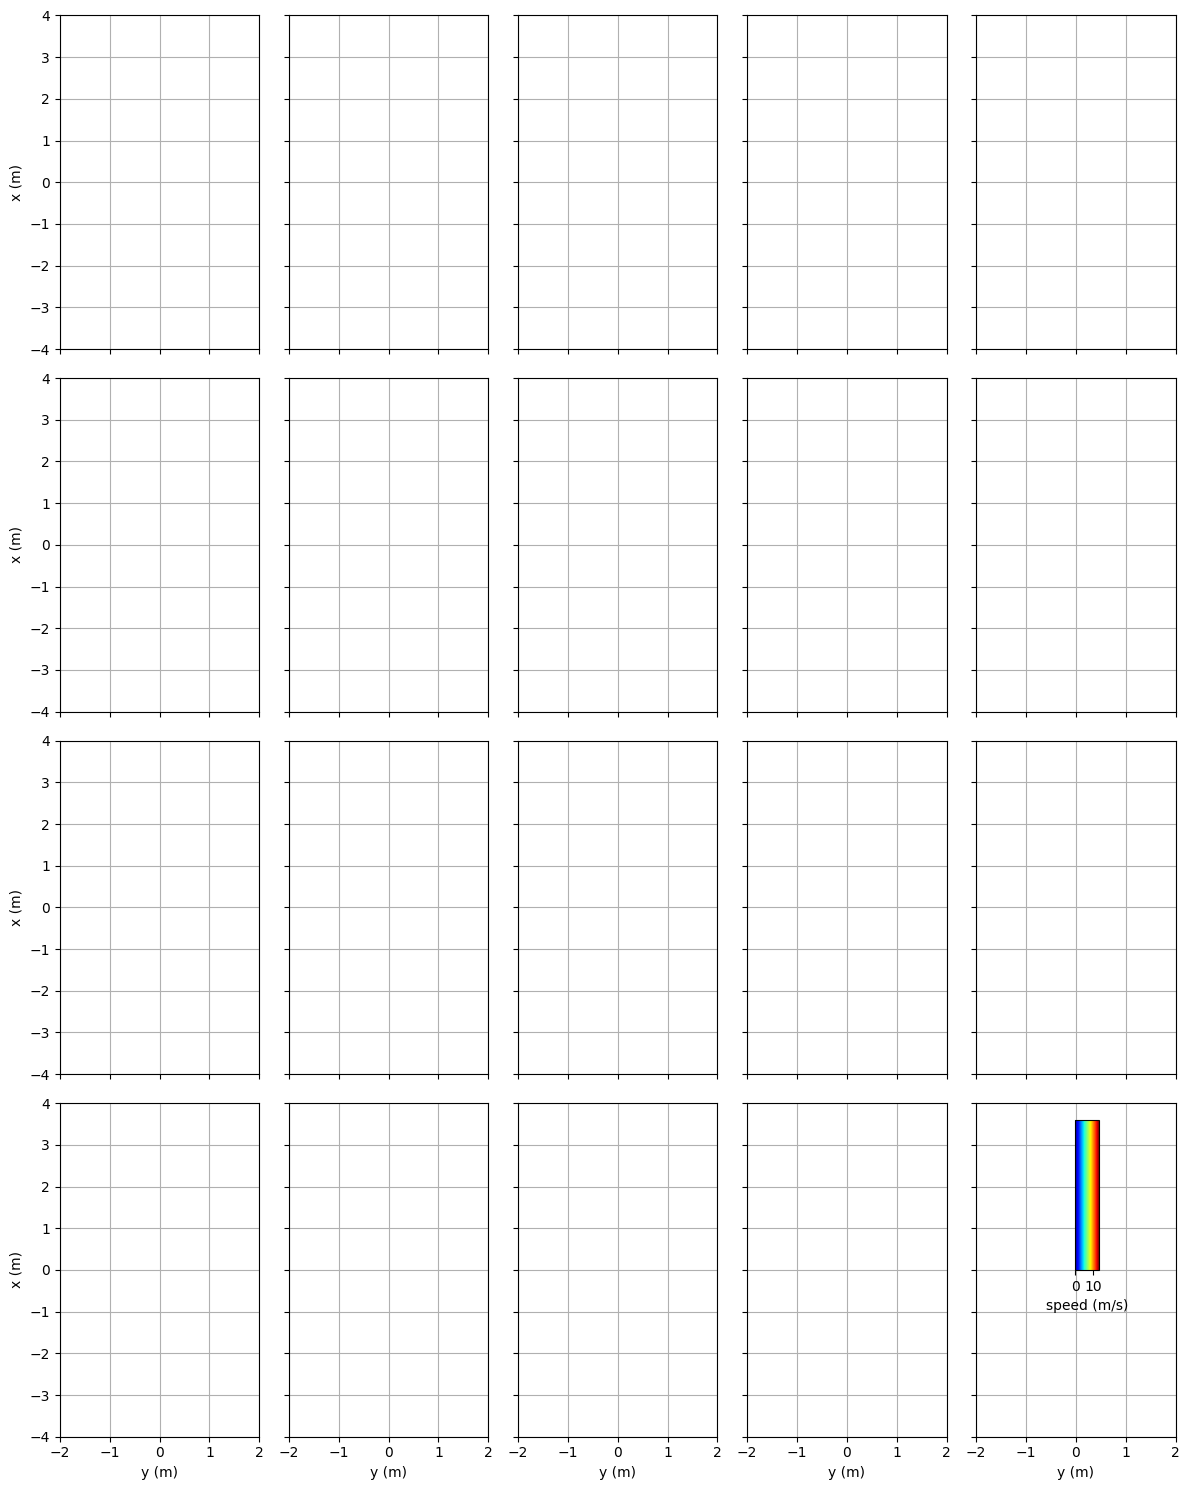

In [111]:
# Create a 2x5 grid of subplots
fig, axs = plt.subplots(4, 5, figsize=(12, 15), sharex='col', sharey='row')

# Adjust the spacing between the two rows
plt.subplots_adjust(wspace=0.1, hspace=0)  # Adjust hspace to add space between the rows

# 3inch runs
runs_3inch = [
    runs_3inch_big_domain_randomization,
    runs_3inch_30percent_randomization,
    runs_3inch_20percent_randomization,
    runs_3inch_10percent_randomization,
    runs_3inch_0percent_randomization
]
names_3inch = ["big", "3inch 30%", "3inch 20%", "3inch 10%", "3inch 0%"]
names_3inch[2] = '$\\bf{3inch\ drone\ real\ flight}$ \n' + names_3inch[2]
runs_3inch_sim = [
    sim_runs_3inch_big_domain_randomization,
    sim_runs_3inch_30percent_randomization,
    sim_runs_3inch_20percent_randomization,
    sim_runs_3inch_10percent_randomization,
    sim_runs_3inch_0percent_randomization
]
names_3inch_sim = ["big", "3inch 30%", "3inch 20%", "3inch 10%", "3inch 0%"]
names_3inch_sim[2] = '$\\bf{3inch\ drone\ simulation}$ \n' + names_3inch_sim[2]
# 5inch runs
runs_5inch = [
    runs_5inch_big_domain_randomization,
    runs_5inch_30percent_randomization,
    runs_5inch_20percent_randomization,
    runs_5inch_10percent_randomization,
    runs_5inch_0percent_randomization
]
names_5inch = ["big", "5inch 30%", "5inch 20%", "5inch 10%", "5inch 0%"]
names_5inch[2] = '$\\bf{5inch\ drone\ real\ flight}$ \n' + names_5inch[2]
runs_5inch_sim = [
    sim_runs_5inch_big_domain_randomization,
    sim_runs_5inch_30percent_randomization,
    sim_runs_5inch_20percent_randomization,
    sim_runs_5inch_10percent_randomization,
    sim_runs_5inch_0percent_randomization
]
names_5inch_sim = ["big", "5inch 30%", "5inch 20%", "5inch 10%", "5inch 0%"]
names_5inch_sim[2] = '$\\bf{5inch\ drone\ simulation}$ \n' + names_5inch_sim[2]

for j in range(5):  # Loop over the columns
    xy_plot(axs[0, j], runs_3inch[j][0], names_3inch[j])
    xy_plot(axs[1, j], runs_3inch_sim[j][0], names_3inch_sim[j], step=1)
    xy_plot(axs[2, j], runs_5inch[j][0], names_5inch[j])
    xy_plot(axs[3, j], runs_5inch_sim[j][0], names_5inch_sim[j], step=1)
    
# invert x-axis
for ax in axs.flatten():
    ax.invert_xaxis()
    
# grid
for ax in axs.flatten():
    ax.grid()
    
# grid lines should be every 1. m
for ax in axs[:, 0]:
    ax.set_yticks(np.arange(-4, 5, 1))
for ax in axs[0, :]:
    ax.set_xticks(np.arange(-2, 3, 1))

# axis labels
for ax in axs[-1, :]:
    ax.set_xlabel('y (m)')
for ax in axs[:, 0]:
    ax.set_ylabel('x (m)')

# # video link    
# video_link = "https://www.youtube.com/watch?v=dQw4w9WgXcQ"
# def put_video_link(ax, url):
#     ax.text(2.55, 3.8, "video", ha='right', va='top', color='blue', fontsize=10, fontweight='bold', url=url, style='italic')
    
# put_video_link(axs[0, 0], video_link)

fig.tight_layout()
fig.savefig("figures/test.pdf")
fig.show()

In [57]:
# runs_3inch[0][0]['episode_info']['ep_reward']
runs_3inch_sim[0][0]['rewards'].sum()

(1200,)

/tmp/ipykernel_2266402/3490729311.py:48: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


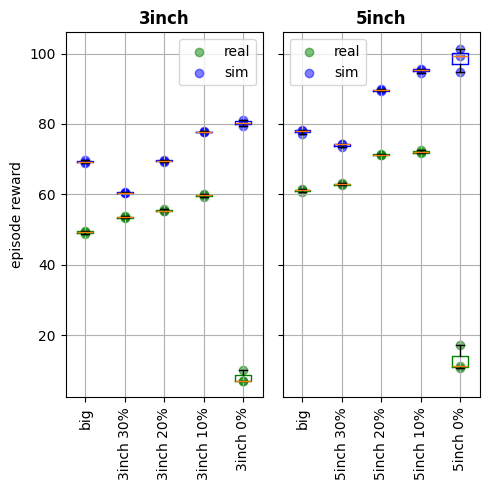

In [89]:
# BOXPLOTS

fig, ax_ = plt.subplots(1, 2, figsize=(5,5), sharey=True, sharex='col')
ax = ax_.flatten()
d = [[runs_3inch[i][j]['episode_info']['ep_reward'] for j in range(3)] for i in range(5)]
ax[0].boxplot(d, positions=[0,1,2,3,4], widths=0.4, vert=True, showfliers=True, boxprops=dict(color='green'))
ax[0].scatter([[0]*3, [1]*3, [2]*3, [3]*3, [4]*3], d, color='green', alpha=0.5, label='real')
d = [[runs_5inch[i][j]['episode_info']['ep_reward'] for j in range(3)] for i in range(5)]
ax[1].boxplot(d, positions=[0,1,2,3,4], widths=0.4, vert=True, showfliers=True, boxprops=dict(color='green'))
ax[1].scatter([[0]*3, [1]*3, [2]*3, [3]*3, [4]*3], d, color='green', alpha=0.5, label='real')
d = [[runs_3inch_sim[i][j]['rewards'].sum() for j in range(3)] for i in range(5)]
ax[0].boxplot(d, positions=[0,1,2,3,4], widths=0.4, vert=True, showfliers=True, boxprops=dict(color='blue'))
ax[0].scatter([[0]*3, [1]*3, [2]*3, [3]*3, [4]*3], d, color='blue', alpha=0.5, label='sim')
d = [[runs_5inch_sim[i][j]['rewards'].sum() for j in range(3)] for i in range(5)]
ax[1].boxplot(d, positions=[0,1,2,3,4], widths=0.4, vert=True, showfliers=True, boxprops=dict(color='blue'))
ax[1].scatter([[0]*3, [1]*3, [2]*3, [3]*3, [4]*3], d, color='blue', alpha=0.5, label='sim')

# title
ax[0].set_title('3inch', fontweight='bold')
ax[1].set_title('5inch', fontweight='bold')
# ax[2].set_title('3inch sim', fontweight='bold')
# ax[3].set_title('5inch sim', fontweight='bold')
# ylabel
ax[0].set_ylabel('episode reward')
# ax[2].set_ylabel('episode reward')
# x ticks
ax[0].set_xticks(range(5))
ax[1].set_xticks(range(5))
# ax[2].set_xticks(range(5))
# ax[3].set_xticks(range(5))

# labeling
# get everything after /n
ax[0].set_xticklabels(['big', '3inch 30%', '3inch 20%', '3inch 10%', '3inch 0%'], rotation=90)
ax[1].set_xticklabels(['big', '5inch 30%', '5inch 20%', '5inch 10%', '5inch 0%'], rotation=90)

# legend
ax[0].legend()
ax[1].legend()

# grid
for a in ax:
    a.grid(True)

# make figure
fig.tight_layout()
fig.savefig('figures/sim_real_boxplot.pdf')
fig.show()

